In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

/home/austin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [14]:
def make_plots_rollout_method(df, boxplot=False, plot_results=True):
    all_df = df.copy()
    
    # Set num_actions to 400 for rows where collision_failure is True
    df.loc[df["collision_failure"] == True, "num_actions"] = 400

    # Set num_actions to 400 for rows where done is False
    df.loc[df["done"] == False, "num_actions"] = 400
    
    # Get unique rollout methods
    rollout_methods = df["rollout_method"].unique()

    # Create a figure for ECDF plots
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot ECDF for each rollout method
    for method in rollout_methods:
        subset = df[df["rollout_method"] == method]["num_actions"]
        sns.ecdfplot(subset, ax=ax, label=f"Method: {method}")

    # Formatting ECDF
    ax.set_title("Empirical CDF of Actions for Completion by Different Rollout Methods")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Rollout Method")

    # Show ECDF plot
    plt.grid(True)
    plt.show()

    if boxplot:
        # Create a box plot comparing rollout methods
        fig, ax = plt.subplots(figsize=(8, 6))

        df.boxplot(column="num_actions", by="rollout_method", ax=ax, patch_artist=True, showmeans=True)

        # Formatting Box Plot
        ax.set_title("Actions for Completion Distribution by Rollout Method")
        ax.set_xlabel("Rollout Method")
        ax.set_ylabel("Number of Actions for Completion")
        plt.suptitle("")  # Remove default title added by pandas boxplot

        # Show Box plot
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    if plot_results:
        # Create a new column 'run_result' with the appropriate labels.
        all_df["run_result"] = np.where(
            df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )

        # Group by rollout_method and run_result, and count occurrences
        counts = all_df.groupby(["rollout_method", "run_result"]).size().unstack(fill_value=0)

        # Reorder the columns so that Collision Failure is at the bottom,
        # then Timeout Failure, and Completed at the top.
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)

        # Plot a stacked bar chart to visualize the distribution
        ax = counts.plot(kind="bar", stacked=True, figsize=(10, 6), color=['green', 'red', 'orange'])
        plt.xticks(rotation=45)
        plt.title("Distribution of Trials Outcomes by Rollout Method")
        plt.xlabel("Rollout Method")
        plt.ylabel("Number of Trials")
        plt.legend(title="Trial Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()
        
def make_plots_hertg_method(df, boxplot=False, plot_results=True):
    # Work on a copy so we don't modify the original dataframe
    all_df = df.copy()
    
    # Set num_actions to 400 for rows where collision_failure is True
    df.loc[df["collision_failure"] == True, "num_actions"] = 400
    # Set num_actions to 400 for rows where done is False
    df.loc[df["done"] == False, "num_actions"] = 400
    
    # Get unique hertg methods
    hertg_methods = df["hertg_method"].unique()

    ### ECDF Plot ###
    fig, ax = plt.subplots(figsize=(8, 6))
    for method in hertg_methods:
        subset = df[df["hertg_method"] == method]["num_actions"]
        sns.ecdfplot(subset, ax=ax, label=f"Method: {method}")
    
    ax.set_title("Empirical CDF of Actions for Completion by Different Hertg Methods")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Hertg Method")
    plt.grid(True)
    plt.show()
    
    ### Box Plot (Optional) ###
    if boxplot:
        fig, ax = plt.subplots(figsize=(8, 6))
        df.boxplot(column="num_actions", by="hertg_method", ax=ax, patch_artist=True, showmeans=True)
        ax.set_title("Actions for Completion Distribution by Hertg Method")
        ax.set_xlabel("Hertg Method")
        ax.set_ylabel("Number of Actions for Completion")
        plt.suptitle("")  # Remove default pandas suptitle
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    ### Stacked Bar Chart of Run Outcomes (Optional) ###
    if plot_results:
        # Create a new column 'run_result' with the appropriate labels.
        all_df["run_result"] = np.where(
            all_df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )
        # Group by hertg_method and run_result, and count occurrences
        counts = all_df.groupby(["hertg_method", "run_result"]).size().unstack(fill_value=0)
        # Reorder the columns: Completed, Collision Failure, then Timeout Failure
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)
        # Plot a stacked bar chart
        ax = counts.plot(kind="bar", stacked=True, figsize=(10, 6), color=['green', 'red', 'orange'])
        plt.xticks(rotation=45)
        plt.title("Distribution of Trial Outcomes by Hertg Method")
        plt.xlabel("Hertg Method")
        plt.ylabel("Number of Trials")
        plt.legend(title="Trial Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()
        
def make_plots_li_hl(df, boxplot=False, plot_results=True):
    # Work on a copy so as not to modify the original dataframe
    all_df = df.copy()
    
    # Set num_actions to 400 for rows where collision_failure is True
    df.loc[df["collision_failure"] == True, "num_actions"] = 400
    # Set num_actions to 400 for rows where done is False
    df.loc[df["done"] == False, "num_actions"] = 400
    
    # Create a new column 'param_combo' that encodes the parameter combination.
    # For the special cases (LI == 25), we use the 'heuristic' column to label.
    def label_row(row):
        if row["LI"] == 25:
            # Check if the heuristic column exists and is True; otherwise assume no heuristic.
            if not row["no_hertg"]:
                return "Exhaustive 1-step w/heuristic"
            else:
                return "Exhaustive 1-step"
        else:
            return f"HL={row['HL']}, LI={row['LI']}"
    
    df["param_combo"] = df.apply(label_row, axis=1)
    
    # Define the desired order for the parameter combinations
    desired_order = [
        'Exhaustive 1-step', 'Exhaustive 1-step w/heuristic', 
        'HL=3, LI=50', 'HL=3, LI=100', 'HL=3, LI=400', 
        'HL=6, LI=50', 'HL=6, LI=100', 'HL=6, LI=400', 
        'HL=9, LI=50', 'HL=9, LI=100', 'HL=9, LI=400'
    ]
    
    # Determine the ordered combinations that are present in the dataframe.
    unique_combos = df["param_combo"].unique()
    ordered_combos = [combo for combo in desired_order if combo in unique_combos]
    
    # (Optional) Print the unique parameter combinations in desired order for verification
    print("Parameter combinations found:", ordered_combos)
    
    ### ECDF Plot ###
    fig, ax = plt.subplots(figsize=(10, 6))
    for combo in ordered_combos:
        subset = df[df["param_combo"] == combo]["num_actions"]
        sns.ecdfplot(subset, ax=ax, label=combo)
    ax.set_title("Empirical CDF of Actions for Completion by Parameter Combination")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Parameter Combination", bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    ### Box Plot (Optional) ###
    if boxplot:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.boxplot(data=df, x="param_combo", y="num_actions", ax=ax, order=ordered_combos)
        ax.set_title("Actions for Completion Distribution by Parameter Combination")
        ax.set_xlabel("Parameter Combination")
        ax.set_ylabel("Number of Actions for Completion")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    
    ### Stacked Bar Chart of Run Outcomes (Optional) ###
    if plot_results:
        # Create a new column 'run_result' with the appropriate labels.
        # Note: We use all_df (the unmodified copy) for run outcomes.
        all_df["run_result"] = np.where(
            all_df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )
        # Also create the param_combo for all_df so that both dataframes match
        all_df["param_combo"] = df["param_combo"]
        
        # Group by param_combo and run_result, and count occurrences
        counts = all_df.groupby(["param_combo", "run_result"]).size().unstack(fill_value=0)
        
        # Reorder the columns so that the order is: Completed, Collision Failure, Timeout Failure.
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)
        
        # Reorder the index (param_combo) to follow our desired ordering
        counts = counts.reindex(ordered_combos)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        counts.plot(kind="bar", stacked=True, ax=ax, color=['green', 'red', 'orange'])
        ax.set_title("Distribution of Run Outcomes by Parameter Combination")
        ax.set_xlabel("Parameter Combination")
        ax.set_ylabel("Number of Trials")
        plt.xticks(rotation=45)
        plt.legend(title="Run Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()



In [18]:
def make_plots_rollout_method(df, boxplot=False, plot_results=True):
    all_df = df.copy()

    # Set num_actions to 400 for rows where collision_failure is True
    df.loc[df["collision_failure"] == True, "num_actions"] = 400
    # Set num_actions to 400 for rows where done is False
    df.loc[df["done"] == False, "num_actions"] = 400

    # Define custom order for rollout methods
    custom_rollout_order = ["same", "random_same", "random", "zero", "accelerate"]

    # Create a figure for ECDF plots
    fig, ax = plt.subplots(figsize=(8, 6))
    # Plot ECDF for each rollout method in the custom order if it exists in the data
    for method in custom_rollout_order:
        if method in df["rollout_method"].unique():
            subset = df[df["rollout_method"] == method]["num_actions"]
            sns.ecdfplot(subset, ax=ax, label=f"Method: {method}")
    ax.set_title("Empirical CDF of Actions for Completion by Different Rollout Methods")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Rollout Method")
    plt.grid(True)
    plt.show()

    if boxplot:
        # Use the custom order for the box plot x-axis
        fig, ax = plt.subplots(figsize=(8, 6))
        df.boxplot(column="num_actions", by="rollout_method", ax=ax, patch_artist=True,
                   showmeans=True, order=custom_rollout_order)
        ax.set_title("Actions for Completion Distribution by Rollout Method")
        ax.set_xlabel("Rollout Method")
        ax.set_ylabel("Number of Actions for Completion")
        plt.suptitle("")  # Remove default title added by pandas
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    if plot_results:
        # Create run_result labels
        all_df["run_result"] = np.where(
            df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )
        # Group by rollout_method and run_result, count occurrences
        counts = all_df.groupby(["rollout_method", "run_result"]).size().unstack(fill_value=0)
        # Reorder the columns (run outcomes) and then the rows (rollout methods)
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)
        counts = counts.reindex(custom_rollout_order)
        # Plot stacked bar chart
        ax = counts.plot(kind="bar", stacked=True, figsize=(10, 6),
                         color=['green', 'red', 'orange'])
        plt.xticks(rotation=45)
        plt.title("Distribution of Trials Outcomes by Rollout Method")
        plt.xlabel("Rollout Method")
        plt.ylabel("Number of Trials")
        plt.legend(title="Trial Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()


def make_plots_hertg_method(df, boxplot=False, plot_results=True):
    all_df = df.copy()

    # Set num_actions to 400 for rows where collision_failure is True
    df.loc[df["collision_failure"] == True, "num_actions"] = 400
    # Set num_actions to 400 for rows where done is False
    df.loc[df["done"] == False, "num_actions"] = 400

    # Define custom order for hertg methods
    custom_hertg_order = ["dynamic", "static"]

    # ECDF Plot with custom order
    fig, ax = plt.subplots(figsize=(8, 6))
    for method in custom_hertg_order:
        if method in df["hertg_method"].unique():
            subset = df[df["hertg_method"] == method]["num_actions"]
            sns.ecdfplot(subset, ax=ax, label=f"Method: {method}")
    ax.set_title("Empirical CDF of Actions for Completion by Different Hertg Methods")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Hertg Method")
    plt.grid(True)
    plt.show()

    if boxplot:
        fig, ax = plt.subplots(figsize=(8, 6))
        df.boxplot(column="num_actions", by="hertg_method", ax=ax, patch_artist=True,
                   showmeans=True, order=custom_hertg_order)
        ax.set_title("Actions for Completion Distribution by Hertg Method")
        ax.set_xlabel("Hertg Method")
        ax.set_ylabel("Number of Actions for Completion")
        plt.suptitle("")  # Remove default pandas suptitle
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    if plot_results:
        all_df["run_result"] = np.where(
            all_df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )
        counts = all_df.groupby(["hertg_method", "run_result"]).size().unstack(fill_value=0)
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)
        counts = counts.reindex(custom_hertg_order)
        ax = counts.plot(kind="bar", stacked=True, figsize=(10, 6),
                         color=['green', 'red', 'orange'])
        plt.xticks(rotation=45)
        plt.title("Distribution of Trial Outcomes by Hertg Method")
        plt.xlabel("Hertg Method")
        plt.ylabel("Number of Trials")
        plt.legend(title="Trial Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()


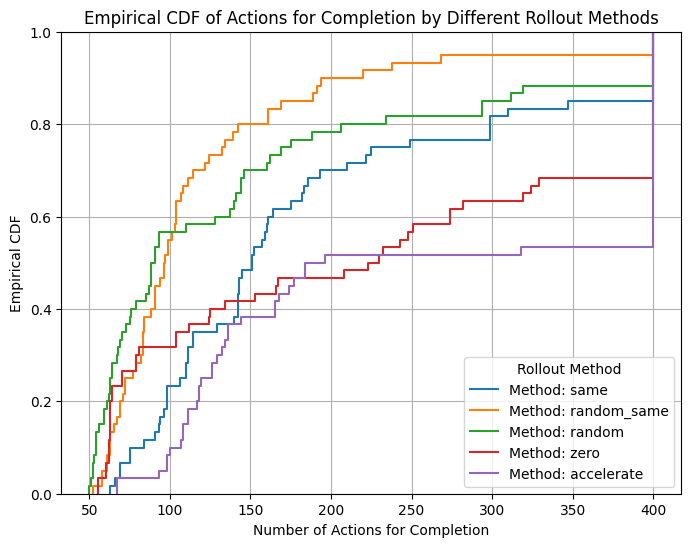

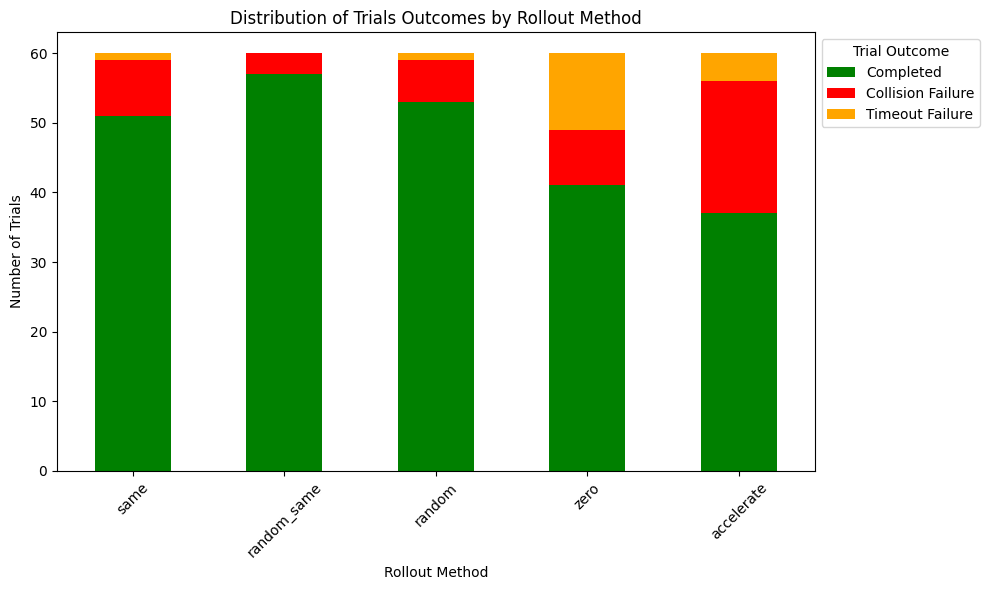

In [19]:
# Load the data
file_path_rollout = "rollout_methods_4configs_15same_400maxactions.csv"
df = pd.read_csv(file_path_rollout)

# Make plots
make_plots_rollout_method(df)

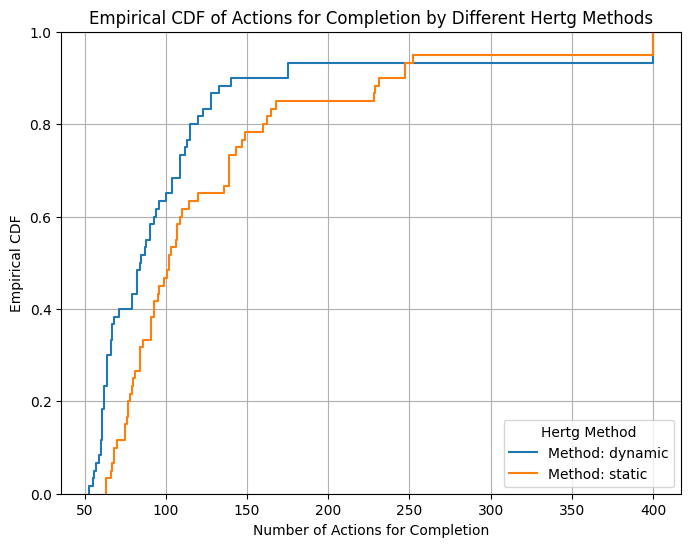

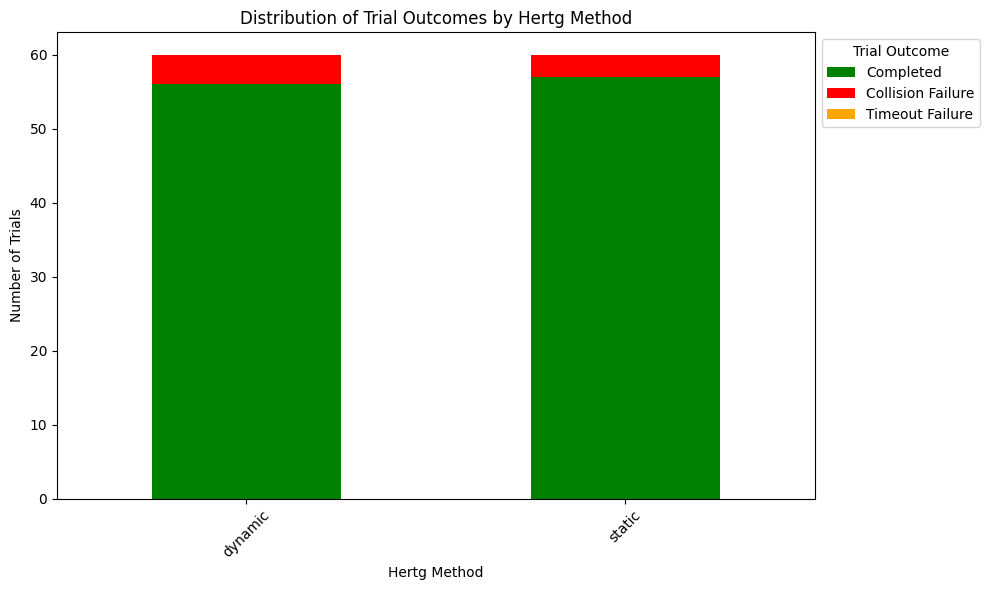

In [20]:
# Load the data
file_path_rollout = "hertg_methods_4configs_15same.csv"
df = pd.read_csv(file_path_rollout)

# Make plots
make_plots_hertg_method(df)

Parameter combinations found: ['Exhaustive 1-step', 'Exhaustive 1-step w/heuristic', 'HL=3, LI=50', 'HL=3, LI=100', 'HL=3, LI=400', 'HL=6, LI=50', 'HL=6, LI=100', 'HL=6, LI=400', 'HL=9, LI=50', 'HL=9, LI=100', 'HL=9, LI=400']


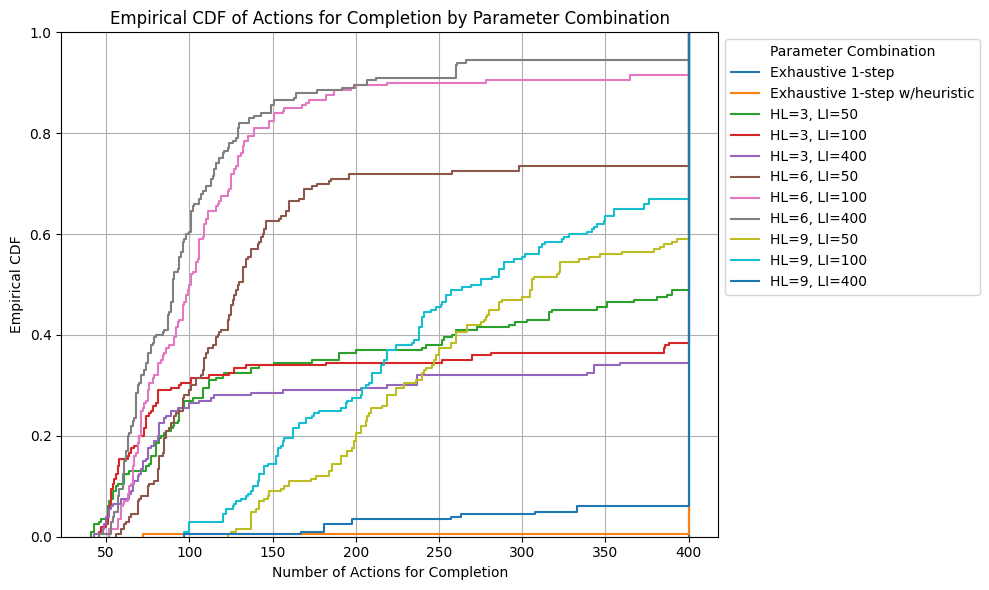

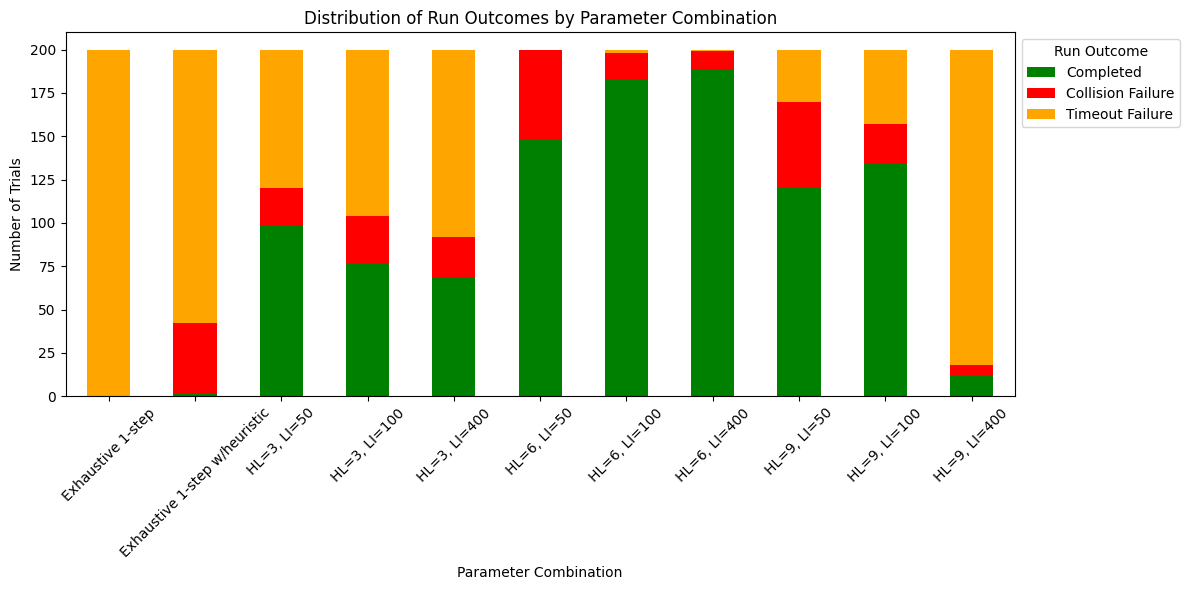

In [15]:
# Load the data
file_path_rollout = "learning_iterations_4configs_50same_[3, 6, 9]hl_[50, 100, 400]li2.csv"
df = pd.read_csv(file_path_rollout)

# Make plots
make_plots_li_hl(df)

In [11]:
# Load the data
file_path_rollout = "learning_iterations_4configs_50same_[3, 6, 9]hl_[50, 100, 400]li2.csv"
df = pd.read_csv(file_path_rollout)

# Filter for only the 1-step options (LI == 25)
ones_df = df[df["LI"] == 25].copy()

# Define the labeling function for the 1-step options
def label_row(row):
    if row["LI"] == 25:
        # If the 'no_hertg' flag is False, we have a heuristic variant
        if not row["no_hertg"]:
            return "Exhaustive 1-step w/heuristic"
        else:
            return "Exhaustive 1-step"
    else:
        return f"HL={row['HL']}, LI={row['LI']}"

# Apply the labeling function to assign 'param_combo'
ones_df["param_combo"] = ones_df.apply(label_row, axis=1)

# Define the labels for the two exhaustive 1-step options
exhaustive_labels = ["Exhaustive 1-step", "Exhaustive 1-step w/heuristic"]

# Loop over the labels and print the counts for each category
for label in exhaustive_labels:
    subset = ones_df[ones_df["param_combo"] == label]
    collision_failures = subset["collision_failure"].sum()  # Sum of True values
    timeouts = (subset["num_actions"] == 400).sum()           # Count where num_actions equals 400
    completions = subset["done"].sum()                        # Sum of True values in done
    print(f"{label}:")
    print(f"  Collision Failures: {collision_failures}")
    print(f"  Timeouts (num_actions==400): {timeouts}")
    print(f"  Completions (done==True): {completions}\n")


Exhaustive 1-step:
  Collision Failures: 0
  Timeouts (num_actions==400): 200
  Completions (done==True): 0

Exhaustive 1-step w/heuristic:
  Collision Failures: 41
  Timeouts (num_actions==400): 158
  Completions (done==True): 1



In [4]:
import pandas as pd

# Load the CSV file
data_file = "learning_iterations_4configs_50same_[3, 6, 9]hl_[50, 100, 400]li2.csv"
df = pd.read_csv(data_file)

# Define a function to label each row by its run type.
def label_row(row):
    # If LI == 25, differentiate based on the heuristic flag.
    if row["LI"] == 25:
        if "no_hertg" in row and not row["no_hertg"]:
            return "Exhaustive 1-step w/heuristic"
        else:
            return "Exhaustive 1-step"
    else:
        return f"HL={row['HL']}, LI={row['LI']}"

# Apply the labeling function to create a new column "param_combo".
df["param_combo"] = df.apply(label_row, axis=1)

# Group by the parameter combination and compute the average of the computation_per_action column.
avg_comp_per_action = df.groupby("param_combo")["computation_per_action"].mean()

# Print the results.
print("Average computation per action by run type:")
print(avg_comp_per_action)


Average computation per action by run type:
param_combo
Exhaustive 1-step                0.055306
Exhaustive 1-step w/heuristic    0.072799
HL=3, LI=100                     0.657930
HL=3, LI=400                     2.513061
HL=3, LI=50                      0.365082
HL=6, LI=100                     1.474362
HL=6, LI=400                     5.697618
HL=6, LI=50                      0.767861
HL=9, LI=100                     2.199458
HL=9, LI=400                     8.176579
HL=9, LI=50                      1.126570
Name: computation_per_action, dtype: float64


/home/austin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Loaded 200 trials for best performing run (HL=6, LI=100)
Parameter combinations found: ['Perfect Sensor', 'Even to 100', 'HL=6, LI=100']


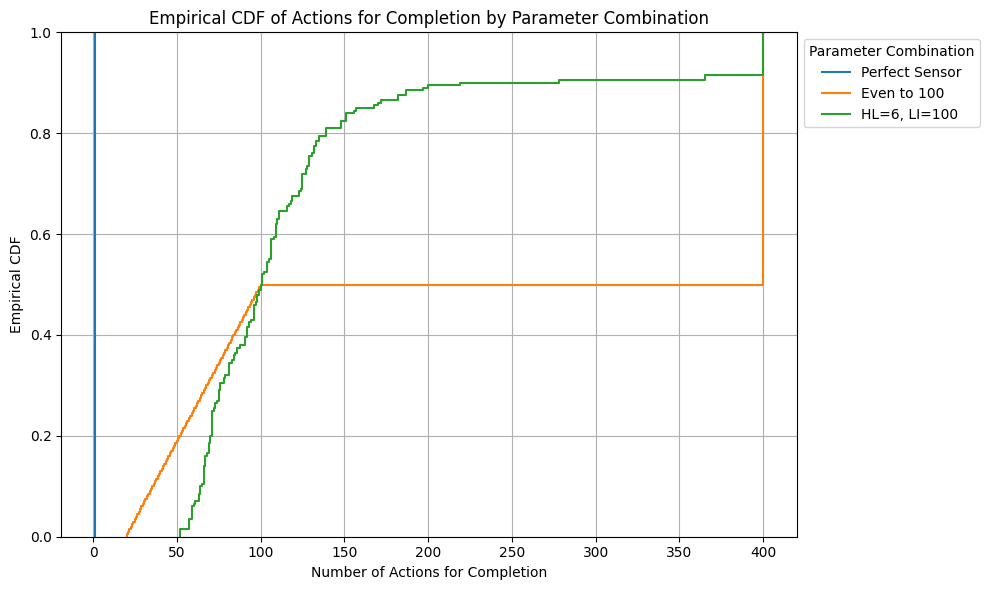

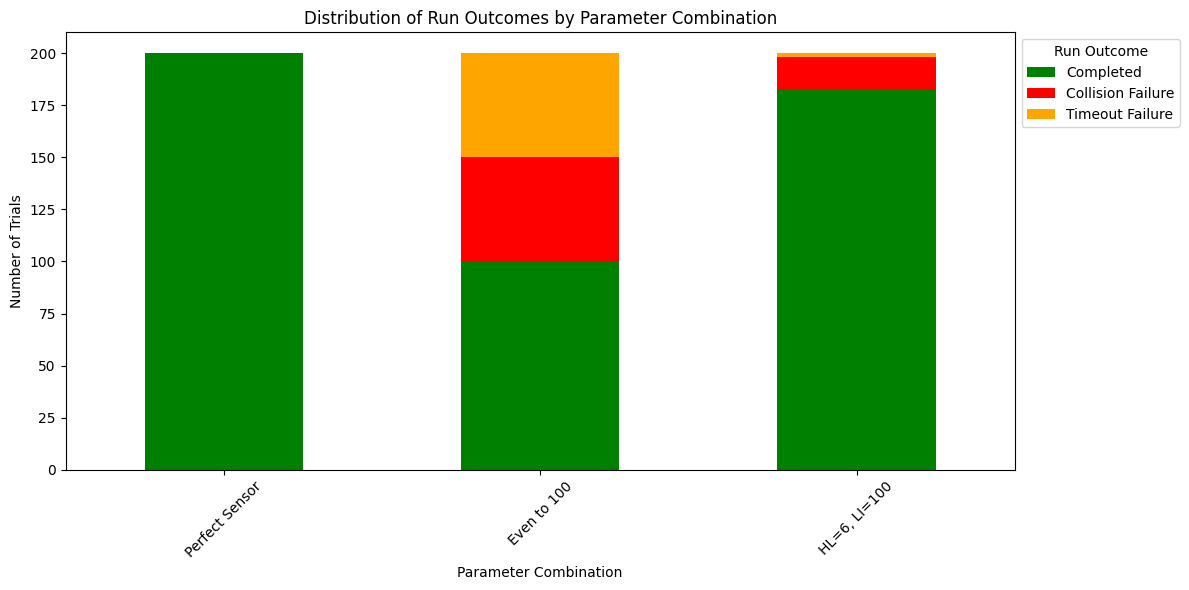

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modified plotting function that supports custom labels
def make_plots_li_hl(df, boxplot=False, plot_results=True):
    # Work on a copy so as not to modify the original dataframe
    all_df = df.copy()
    
    # Set num_actions to 400 for rows where collision_failure is True or done is False
    df.loc[df["collision_failure"] == True, "num_actions"] = 400
    df.loc[df["done"] == False, "num_actions"] = 400
    
    # Use custom labels if provided; otherwise use the default labeling
    if "custom_param_combo" in df.columns:
        df["param_combo"] = df["custom_param_combo"]
    else:
        def label_row(row):
            if row["LI"] == 25:
                if "no_hertg" in row and not row["no_hertg"]:
                    return "Exhaustive 1-step w/heuristic"
                else:
                    return "Exhaustive 1-step"
            else:
                return f"HL={row['HL']}, LI={row['LI']}"
        df["param_combo"] = df.apply(label_row, axis=1)
    
    # Define the custom ordering for our three sensor types.
    desired_order = ["Perfect Sensor", "Even to 100", "HL=6, LI=100"]
    unique_combos = df["param_combo"].unique()
    ordered_combos = [combo for combo in desired_order if combo in unique_combos]
    
    print("Parameter combinations found:", ordered_combos)
    
    ### ECDF Plot ###
    fig, ax = plt.subplots(figsize=(10, 6))
    for combo in ordered_combos:
        subset = df[df["param_combo"] == combo]["num_actions"]
        sns.ecdfplot(subset, ax=ax, label=combo)
    ax.set_title("Empirical CDF of Actions for Completion by Parameter Combination")
    ax.set_xlabel("Number of Actions for Completion")
    ax.set_ylabel("Empirical CDF")
    ax.legend(title="Parameter Combination", bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    ### Stacked Bar Chart of Run Outcomes ###
    if plot_results:
        # Determine run outcome:
        # If done is True, then Completed;
        # if done is False and collision_failure is True, then Collision Failure;
        # otherwise, Timeout Failure.
        all_df["run_result"] = np.where(
            all_df["done"] == True, "Completed",
            np.where(all_df["collision_failure"] == True, "Collision Failure", "Timeout Failure")
        )
        # Ensure both dataframes have matching parameter combination labels
        all_df["param_combo"] = df["param_combo"]
        
        # Group by parameter combination and run outcome, then reindex for custom ordering.
        counts = all_df.groupby(["param_combo", "run_result"]).size().unstack(fill_value=0)
        ordered_categories = ["Completed", "Collision Failure", "Timeout Failure"]
        counts = counts.reindex(columns=ordered_categories)
        counts = counts.reindex(ordered_combos)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        counts.plot(kind="bar", stacked=True, ax=ax, color=['green', 'red', 'orange'])
        ax.set_title("Distribution of Run Outcomes by Parameter Combination")
        ax.set_xlabel("Parameter Combination")
        ax.set_ylabel("Number of Trials")
        plt.xticks(rotation=45)
        plt.legend(title="Run Outcome", loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()


# ----- Create Example Data for Two Artificial Runs -----

# 1. Perfect Sensor: 200 trials, all complete in 1 action.
perfect_sensor = pd.DataFrame({
    "LI": [0]*200,
    "HL": [0]*200,
    "num_actions": [1]*200,
    "done": [True]*200,
    "collision_failure": [False]*200,
    "custom_param_combo": ["Perfect Sensor"]*200
})

# 2. Even to 100: 200 trials.
#    - 100 successful trials: evenly distributed actions from 20 to 100.
even_success = pd.DataFrame({
    "LI": [0]*100,
    "HL": [0]*100,
    "num_actions": np.linspace(20, 100, 100),
    "done": [True]*100,
    "collision_failure": [False]*100,
    "custom_param_combo": ["Even to 100"]*100
})
#    - 100 failure trials: all assigned 400 actions.
#         50 due to collision (done False, collision_failure True)
even_failure_collision = pd.DataFrame({
    "LI": [0]*50,
    "HL": [0]*50,
    "num_actions": [400]*50,
    "done": [False]*50,
    "collision_failure": [True]*50,
    "custom_param_combo": ["Even to 100"]*50
})
#         50 due to timeout (done False, collision_failure False)
even_failure_timeout = pd.DataFrame({
    "LI": [0]*50,
    "HL": [0]*50,
    "num_actions": [400]*50,
    "done": [False]*50,
    "collision_failure": [False]*50,
    "custom_param_combo": ["Even to 100"]*50
})
even_to_100 = pd.concat([even_success, even_failure_collision, even_failure_timeout], ignore_index=True)


# ----- Load Best Performing Run Data from CSV -----

data_file = "learning_iterations_4configs_50same_[3, 6, 9]hl_[50, 100, 400]li2.csv"
try:
    data_df = pd.read_csv(data_file)
    # Filter for HL==6 and LI==100
    best_run = data_df[(data_df["HL"] == 6) & (data_df["LI"] == 100)].copy()
    # Set the custom label for plotting
    best_run["custom_param_combo"] = "HL=6, LI=100"
    print(f"Loaded {len(best_run)} trials for best performing run (HL=6, LI=100)")
except Exception as e:
    print(f"Error loading data file: {e}")
    best_run = pd.DataFrame()  # Use an empty DataFrame if the file cannot be loaded.

# ----- Combine All Data and Generate the Plots -----

df_example = pd.concat([perfect_sensor, even_to_100, best_run], ignore_index=True)
make_plots_li_hl(df_example, boxplot=False, plot_results=True)
